# Study: Vision Transformer (ViT) Features + SVM Classification

This notebook demonstrates feature extraction from Vision Transformer models and classification using SVM.

## Methodology
- **Feature Extraction**: Extract global features from ViT models using [CLS] token (classification head removed)
- **Model**: ViT-Base-Patch16-224 (from HuggingFace)
- **Classifier**: Support Vector Machine (SVM) with RBF kernel
- **Dataset**: UCMerced Land Use Dataset (21 classes)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import time

from data import DataLoader
from config import ExperimentConfig
from features import FeatureExtractor

# Set style for better plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


/home/ayoub/miniconda3/envs/develop/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-11-30 13:49:03.011557: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1. Load Data


In [ ]:
# Configuration
config = ExperimentConfig(
    data_dir="UCMerced_LandUse",
    classifier_type="svm",
    svm_kernel="rbf",
    svm_C=1.0,
    use_feature_scaling=True,
    vit_model_name="google/vit-base-patch16-224-in21k",
)

# Load data
print("Loading images...")
data_loader = DataLoader(config)
images, labels, class_names = data_loader.load_images_and_labels()

print(f"\nDataset Statistics:")
print(f"  Total images: {len(images)}")
print(f"  Number of classes: {len(class_names)}")
print(f"  Classes: {class_names}")


Loading images...
Loading images from: UCMerced_LandUse
Found classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']
Loaded 2100 images from 21 classes

Dataset Statistics:
  Total images: 2100
  Number of classes: 21
  Classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']


## 2. Extract ViT Features (Using [CLS] Token)


In [3]:
# Extract features using ViT ([CLS] token, classification head removed)
print(f"Extracting features using Vision Transformer...")
print(f"Model: {config.vit_model_name}")
print("Note: Using [CLS] token embedding as global feature (classification head removed)\n")

feature_extractor = FeatureExtractor(config)
start_time = time.time()
features = feature_extractor.vit_feature_extraction(images, model_name=config.vit_model_name)
extraction_time = time.time() - start_time

print(f"\nFeature Extraction Complete!")
print(f"  Features shape: {features.shape}")
print(f"  Extraction time: {extraction_time:.2f} seconds")
print(f"  Feature dimension: {features.shape[1]}")


Extracting features using Vision Transformer...
Model: google/vit-base-patch16-224-in21k
Note: Using [CLS] token embedding as global feature (classification head removed)

Loading ViT model: google/vit-base-patch16-224-in21k
  2025-11-30T12:49:44.862659Z  WARN  Reqwest(reqwest::Error { kind: Request, url: "https://transfer.xethub.hf.co/xorbs/default/f906a0a3b200bbd8815f61689cbc429e1706767027c3575648ee9beb34b1a511?X-Xet-Signed-Range=bytes%3D7187744-16075511&X-Xet-Session-Id=01KBACYQ0SWDSKY765ZG1ZJEXF&Expires=1764510552&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly90cmFuc2Zlci54ZXRodWIuaGYuY28veG9yYnMvZGVmYXVsdC9mOTA2YTBhM2IyMDBiYmQ4ODE1ZjYxNjg5Y2JjNDI5ZTE3MDY3NjcwMjdjMzU3NTY0OGVlOWJlYjM0YjFhNTExP1gtWGV0LVNpZ25lZC1SYW5nZT1ieXRlcyUzRDcxODc3NDQtMTYwNzU1MTEmWC1YZXQtU2Vzc2lvbi1JZD0wMUtCQUNZUTBTV0RTS1k3NjVaRzFaSkVYRiIsIkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc2NDUxMDU1Mn19fV19&Signature=MEUCIAqJ9M6BO4VeiEWUZ6gURlidJIjTdsWcLJoShJQiP~njAiEAqpeSwiorntwEPdp-lcyJJLxBI6

## 3. Train/Test Split


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, 
    test_size=0.2, 
    random_state=42,
    stratify=labels
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Feature dimension: {X_train.shape[1]}")


Training set: 1680 samples
Test set: 420 samples
Feature dimension: 768


## 4. Feature Scaling


In [5]:
if config.use_feature_scaling:
    print("Applying StandardScaler to features...")
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    print("Feature scaling complete!")
else:
    print("Feature scaling disabled.")


Applying StandardScaler to features...
Feature scaling complete!


## 5. Train SVM Classifier


In [6]:
print(f"Training SVM with {config.svm_kernel.upper()} kernel...")
print(f"  C: {config.svm_C}")

clf = svm.SVC(
    kernel=config.svm_kernel, 
    C=config.svm_C,
    gamma='scale',
    random_state=42
)

train_start = time.time()
clf.fit(X_train, y_train)
train_time = time.time() - train_start

print(f"\nTraining complete! Time: {train_time:.2f} seconds")


Training SVM with RBF kernel...
  C: 1.0

Training complete! Time: 0.45 seconds


## 6. Evaluate Model


In [7]:
# Make predictions
y_pred = clf.predict(X_test)

# Calculate metrics
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = metrics.recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = metrics.f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("="*60)


MODEL PERFORMANCE METRICS
Accuracy:  0.9214 (92.14%)
Precision: 0.9290
Recall:    0.9214
F1-Score:  0.9223


## 7. Visualizations

### 7.1 Confusion Matrix


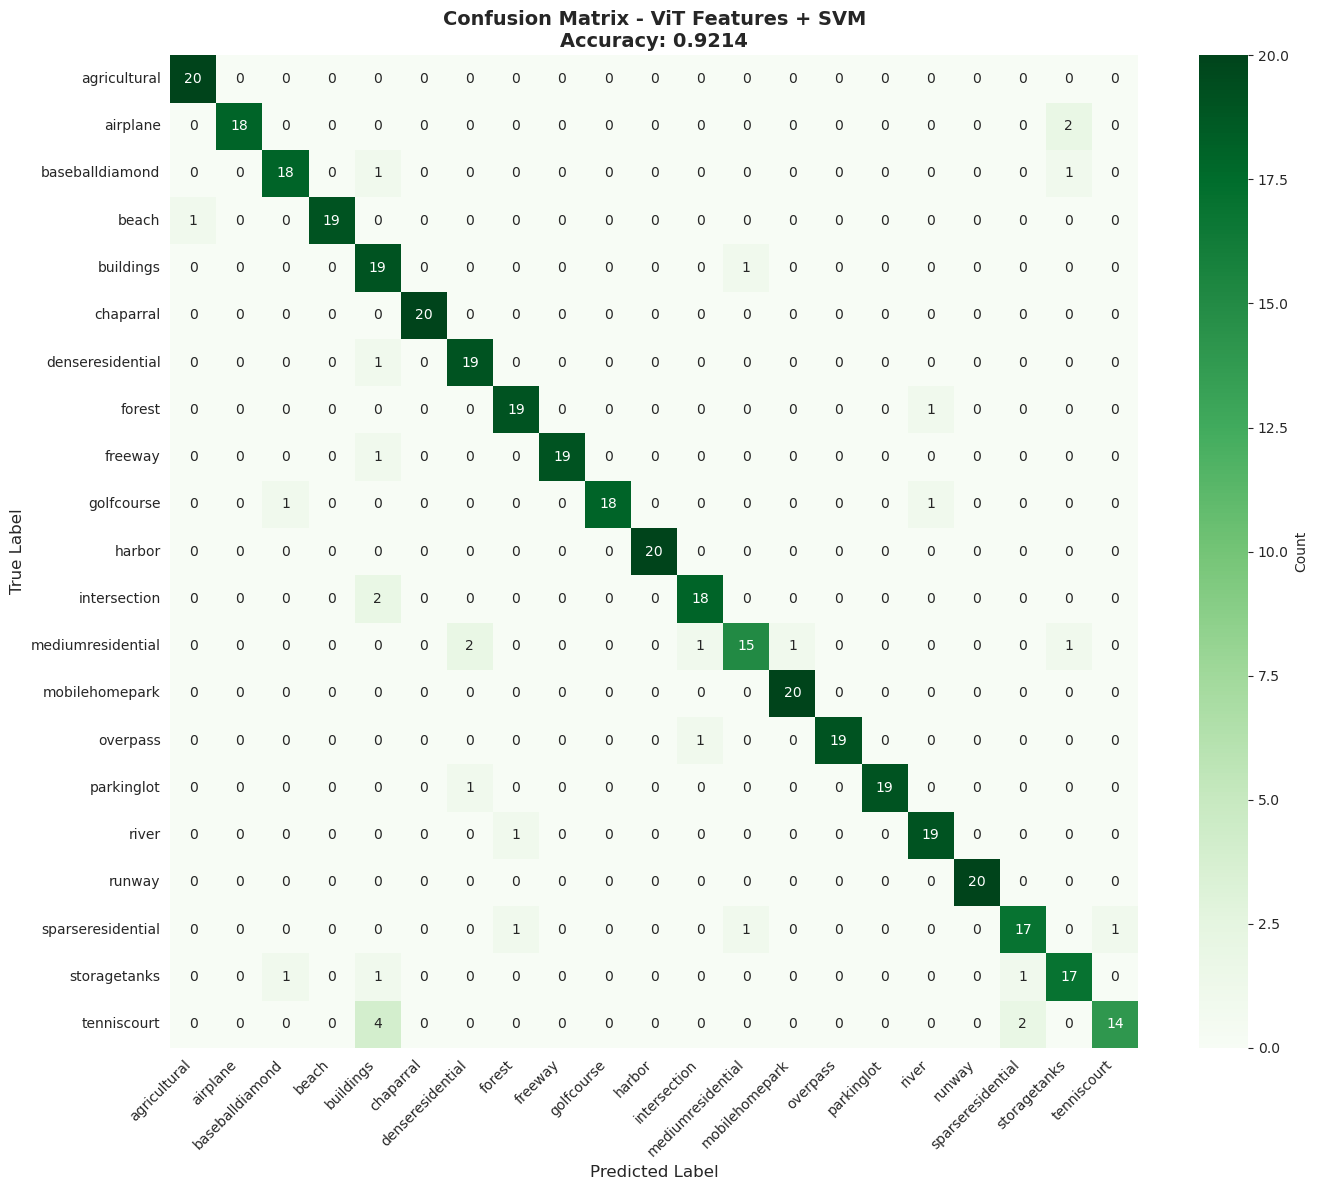

In [8]:
conf_matrix = metrics.confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - ViT Features + SVM\nAccuracy: {accuracy:.4f}', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 7.2 Per-Class Performance Metrics


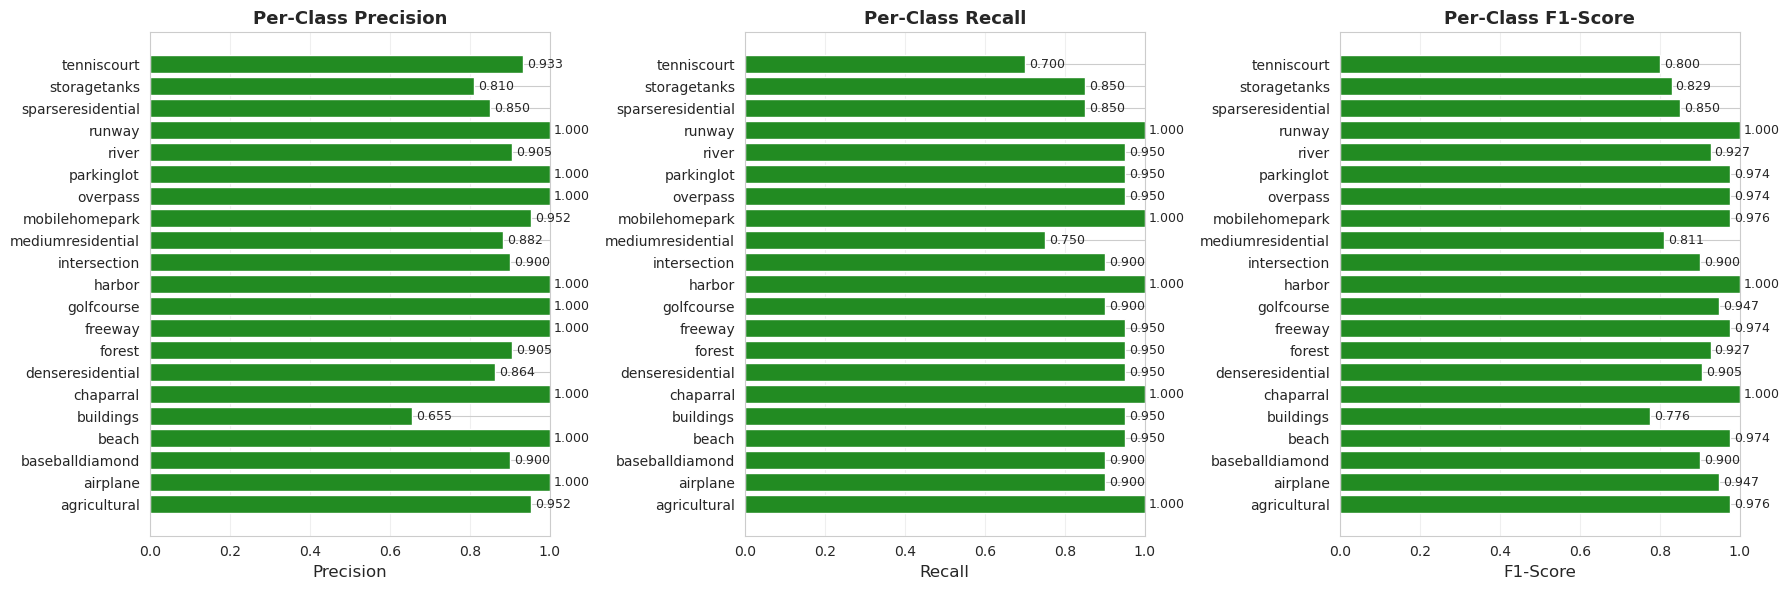


Per-Class Performance Metrics:
            Class  Precision  Recall  F1-Score  Support
     agricultural   0.952381    1.00  0.975610     20.0
         airplane   1.000000    0.90  0.947368     20.0
  baseballdiamond   0.900000    0.90  0.900000     20.0
            beach   1.000000    0.95  0.974359     20.0
        buildings   0.655172    0.95  0.775510     20.0
        chaparral   1.000000    1.00  1.000000     20.0
 denseresidential   0.863636    0.95  0.904762     20.0
           forest   0.904762    0.95  0.926829     20.0
          freeway   1.000000    0.95  0.974359     20.0
       golfcourse   1.000000    0.90  0.947368     20.0
           harbor   1.000000    1.00  1.000000     20.0
     intersection   0.900000    0.90  0.900000     20.0
mediumresidential   0.882353    0.75  0.810811     20.0
   mobilehomepark   0.952381    1.00  0.975610     20.0
         overpass   1.000000    0.95  0.974359     20.0
       parkinglot   1.000000    0.95  0.974359     20.0
            rive

In [9]:
# Get per-class metrics
report = metrics.classification_report(y_test, y_pred, target_names=class_names, output_dict=True)

# Extract metrics for each class
class_metrics = []
for class_name in class_names:
    if class_name in report:
        class_metrics.append({
            'Class': class_name,
            'Precision': report[class_name]['precision'],
            'Recall': report[class_name]['recall'],
            'F1-Score': report[class_name]['f1-score'],
            'Support': report[class_name]['support']
        })

metrics_df = pd.DataFrame(class_metrics)

# Plot per-class metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics_to_plot = ['Precision', 'Recall', 'F1-Score']
for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    bars = ax.barh(range(len(metrics_df)), metrics_df[metric], color='forestgreen')
    ax.set_yticks(range(len(metrics_df)))
    ax.set_yticklabels(metrics_df['Class'])
    ax.set_xlabel(metric, fontsize=12)
    ax.set_title(f'Per-Class {metric}', fontsize=13, fontweight='bold')
    ax.set_xlim([0, 1])
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, metrics_df[metric])):
        ax.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Display metrics table
print("\nPer-Class Performance Metrics:")
print(metrics_df.to_string(index=False))


### 7.3 Classification Report


In [10]:
print("\nDetailed Classification Report:")
print("="*60)
print(metrics.classification_report(y_test, y_pred, target_names=class_names))
print("="*60)



Detailed Classification Report:
                   precision    recall  f1-score   support

     agricultural       0.95      1.00      0.98        20
         airplane       1.00      0.90      0.95        20
  baseballdiamond       0.90      0.90      0.90        20
            beach       1.00      0.95      0.97        20
        buildings       0.66      0.95      0.78        20
        chaparral       1.00      1.00      1.00        20
 denseresidential       0.86      0.95      0.90        20
           forest       0.90      0.95      0.93        20
          freeway       1.00      0.95      0.97        20
       golfcourse       1.00      0.90      0.95        20
           harbor       1.00      1.00      1.00        20
     intersection       0.90      0.90      0.90        20
mediumresidential       0.88      0.75      0.81        20
   mobilehomepark       0.95      1.00      0.98        20
         overpass       1.00      0.95      0.97        20
       parkinglot     

### 7.4 Overall Metrics Summary


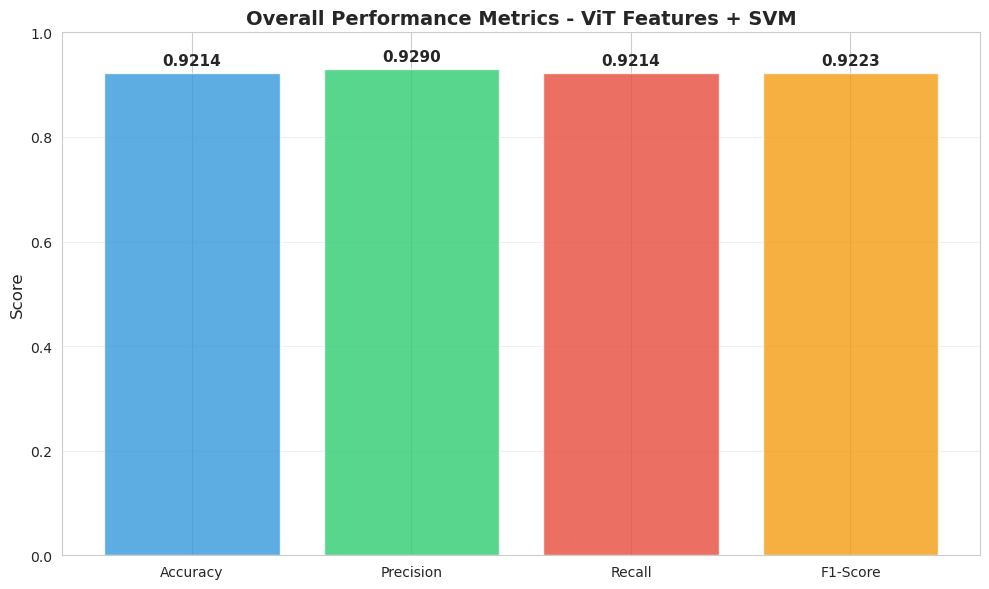

In [11]:
# Create summary bar plot
metrics_summary = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(metrics_summary.keys(), metrics_summary.values(), 
               color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'], alpha=0.8)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Overall Performance Metrics - ViT Features + SVM', 
             fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, (metric, value) in zip(bars, metrics_summary.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{value:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


## 8. Summary


In [12]:
print("="*60)
print("STUDY SUMMARY")
print("="*60)
print(f"Feature Extraction Method: Vision Transformer (ViT)")
print(f"  - Model: {config.vit_model_name}")
print(f"  - Using [CLS] token embedding (classification head removed)")
print(f"  - Feature dimension: {features.shape[1]}")
print(f"  - Extraction time: {extraction_time:.2f} seconds")
print(f"\nClassifier: SVM")
print(f"  - Kernel: {config.svm_kernel.upper()}")
print(f"  - C: {config.svm_C}")
print(f"  - Training time: {train_time:.2f} seconds")
print(f"\nPerformance:")
print(f"  - Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print("="*60)


STUDY SUMMARY
Feature Extraction Method: Vision Transformer (ViT)
  - Model: google/vit-base-patch16-224-in21k
  - Using [CLS] token embedding (classification head removed)
  - Feature dimension: 768
  - Extraction time: 485.39 seconds

Classifier: SVM
  - Kernel: RBF
  - C: 1.0
  - Training time: 0.45 seconds

Performance:
  - Accuracy:  0.9214 (92.14%)
  - Precision: 0.9290
  - Recall:    0.9214
  - F1-Score:  0.9223
